In [1]:
from pathlib import Path
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import substring
from shapely.geometry import LineString, MultiPoint
from shapely import hausdorff_distance, frechet_distance

In [2]:
ROOT = Path("../..")
CRS = "EPSG:23700"

gdf_gt   = gpd.read_file(ROOT / "data/manual_annotation/trace.gpkg").to_crs(CRS)
gdf_algo = gpd.read_file(ROOT / "data/output/cegl_2/car_trace/geopackage/window_median_v2.gpkg").to_crs(CRS)

ground_truth: LineString = gdf_gt.geometry.iloc[0]
trace_algo: LineString   = gdf_algo.geometry.iloc[0]

print(f"GT length:   {ground_truth.length:.1f} m")
print(f"Algo length: {trace_algo.length:.1f} m")

GT length:   4703.4 m
Algo length: 4778.3 m


In [3]:
# Project GT first and last points onto trace_algo, then trim
d_start = trace_algo.project(ground_truth.boundary.geoms[0])
d_end   = trace_algo.project(ground_truth.boundary.geoms[1])

if d_start > d_end:
    d_start, d_end = d_end, d_start

trace_algo = substring(trace_algo, d_start, d_end)

print(f"Trimmed algo length: {trace_algo.length:.1f} m  (kept {d_start:.1f} – {d_end:.1f} m)")

Trimmed algo length: 4700.6 m  (kept 37.5 – 4738.0 m)


In [4]:
def sample_line(line: LineString, step: float = 0.3) -> np.ndarray:
    """Return Nx2 array of points sampled every `step` metres along the line."""
    distances = np.arange(0, line.length, step)
    pts = [line.interpolate(d) for d in distances]
    return np.array([(p.x, p.y) for p in pts])

pts_GT   = sample_line(ground_truth)
pts_Algo = sample_line(trace_algo)

print(f"pts_GT:   {len(pts_GT)} points")
print(f"pts_Algo: {len(pts_Algo)} points")

pts_GT:   15679 points
pts_Algo: 15669 points


In [5]:
# For each GT point: distance to trace_algo line
gt_pts_geom = MultiPoint(pts_GT)
dist_GT_to_Algo = np.array([trace_algo.distance(p) for p in gt_pts_geom.geoms])

# For each Algo point: distance to ground_truth line
algo_pts_geom = MultiPoint(pts_Algo)
dist_Algo_to_GT = np.array([ground_truth.distance(p) for p in algo_pts_geom.geoms])

In [6]:
def metrics(dists: np.ndarray) -> dict:
    return {
        "Mean Error": f"{dists.mean():.3f} m",
        "RMSE":       f"{np.sqrt((dists**2).mean()):.3f} m",
        "P95":        f"{np.percentile(dists, 95):.3f} m",
        "P99":        f"{np.percentile(dists, 99):.3f} m",
    }

m_gt   = metrics(dist_GT_to_Algo)
m_algo = metrics(dist_Algo_to_GT)

header = f"{'Metric':<16} {'Mean Error':>12} {'RMSE':>10} {'P95':>10} {'P99':>10}"
sep    = "-" * len(header)
row_gt   = f"{'GT -> Algo':<16} {m_gt['Mean Error']:>12} {m_gt['RMSE']:>10} {m_gt['P95']:>10} {m_gt['P99']:>10}"
row_algo = f"{'Algo -> GT':<16} {m_algo['Mean Error']:>12} {m_algo['RMSE']:>10} {m_algo['P95']:>10} {m_algo['P99']:>10}"

print(header)
print(sep)
print(row_gt)
print(row_algo)

Metric             Mean Error       RMSE        P95        P99
--------------------------------------------------------------
GT -> Algo            0.177 m    0.305 m    0.508 m    1.527 m
Algo -> GT            0.176 m    0.303 m    0.506 m    1.522 m


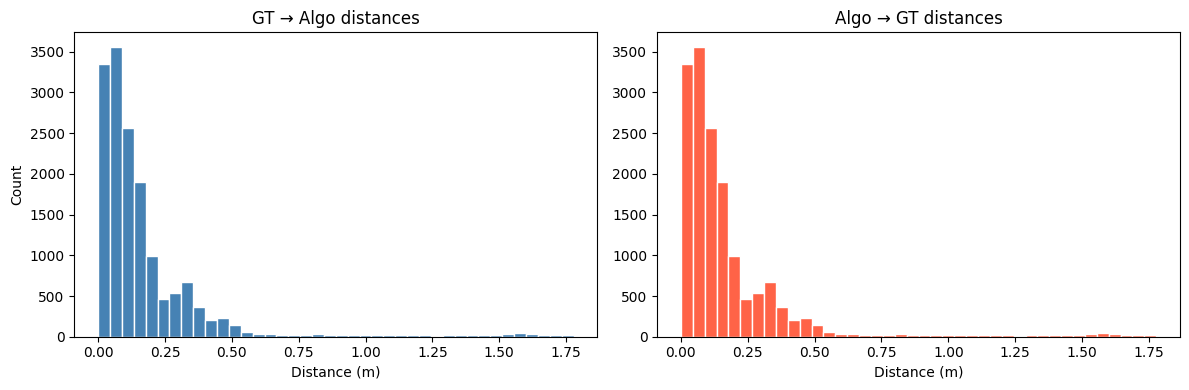

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

ax1.hist(dist_GT_to_Algo, bins=40, color="steelblue", edgecolor="white")
ax1.set_title("GT → Algo distances")
ax1.set_xlabel("Distance (m)")
ax1.set_ylabel("Count")

ax2.hist(dist_Algo_to_GT, bins=40, color="tomato", edgecolor="white")
ax2.set_title("Algo → GT distances")
ax2.set_xlabel("Distance (m)")

plt.tight_layout()
plt.show()

In [8]:
sample_len = 0.3
densify = sample_len / ground_truth.length
hausdorff = hausdorff_distance(ground_truth, trace_algo, densify=densify)

print(f"Hausdorff distance: {hausdorff:.3f} m")

Hausdorff distance: 1.782 m
